<a href="https://colab.research.google.com/github/sanmquin/AI/blob/main/research/4.Centrality-Ordering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Centrality and Description Ordering

This notebook tests the intuition that **central topics in a channel's content should appear
early and prominently in its prose description**, mirroring the structure of the point cloud
where core videos lie close to the centroid.

For each channel two centrality rankings are computed:

1. **Point-cloud centrality rank**: videos are ranked by their distance from the channel centroid
   in 20D space.  Videos closest to the centroid (rank 1) represent the most typical content.
2. **Description segment centrality rank**: segments are embedded and ranked by their distance
   from the description centroid (the mean segment embedding).  Segments closest to the
   description centre represent the channel's most representative semantic content.

The hypothesis is that **early segments in the written description** (those the author wrote
first) correspond to **more central segment embeddings** — i.e., narrative ordering mirrors
semantic centrality.  A per-channel Spearman correlation between segment position (index) and
centrality rank is computed and aggregated into a final summary.


## 1) Setup

Install dependencies and mount Drive.


In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn scipy sentence-transformers

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

try:
    from google.colab import drive
    drive.mount('/content/drive')
    is_colab = True
except ImportError:
    print('Not running in Colab — headless mode.')
    is_colab = False


Mounted at /content/drive


## 2) Load data

Load the 20D video embeddings and the segmented descriptions produced by
`3.Shape-vs-Description.ipynb`.  The chunk artifact contains each channel's description
already split into ordered segments.


In [2]:
DATA_PATH = Path(
    '/content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/'
    'business_cluster_video_embeddings_reduced_20d.csv'
)
CHUNKS_PATH = Path('/content/drive/MyDrive/Research/channel_chunks/latest/all_chunks.json')

RESEARCH_ROOT = Path('/content/drive/MyDrive/Research') if is_colab else Path('./research_output')

if not DATA_PATH.exists():
    print('Warning: embedding CSV not found — using dummy data.')
    rng = np.random.default_rng(2)
    channel_names = [f'Channel_{c}' for c in ['Alpha', 'Beta', 'Gamma', 'Delta', 'Epsilon']]
    rows = []
    for i in range(200):
        ch = channel_names[i % len(channel_names)]
        rows.append({
            'video_id': f'vid_{i}', 'channel_id': f'ch_{i%5}', 'channel_name': ch,
            'video_title': f'Video {i}', 'view_count': int(rng.integers(1000, 100000)),
            **{f'embedding_reduced_{j+1:02d}': float(rng.standard_normal()) for j in range(20)},
        })
    df = pd.DataFrame(rows)
else:
    df = pd.read_csv(DATA_PATH)

channel_col = 'channel_name' if 'channel_name' in df.columns else 'channel_id'
dim_cols    = sorted([c for c in df.columns if c.startswith('embedding_reduced_')])
channels    = df[channel_col].dropna().unique().tolist()

if not CHUNKS_PATH.exists():
    print('Warning: chunk file not found — creating dummy 4-segment descriptions.')
    all_chunks = {
        ch: {'segments': [
            f'{ch} primarily focuses on technology and innovation.',
            f'The channel features interviews with leading entrepreneurs.',
            f'Investment strategy and market analysis are recurring topics.',
            f'Educational content about personal growth rounds out the offering.',
        ]}
        for ch in channels
    }
else:
    with open(CHUNKS_PATH) as fh:
        raw = json.load(fh)
    all_chunks = {ch: data for ch, data in raw.get('channels', {}).items() if ch in channels}

channels = [ch for ch in channels if ch in all_chunks]
print(f'Loaded {len(df):,} videos, {len(channels)} aligned channels.')


Loaded 1,344 videos, 27 aligned channels.


## 3) Point-cloud centrality

For each channel, compute the Euclidean distance of every video embedding from the channel
centroid.  Videos are then ranked from most central (rank 1 = closest to centroid) to most
peripheral.  The centroid represents the channel's "average" content.  Peripheral videos are
outliers that explore topics further from the channel's core identity.


In [3]:
clouds    = {ch: df[df[channel_col] == ch][dim_cols].dropna().values for ch in channels}
centroids = {ch: clouds[ch].mean(axis=0) for ch in channels}

pc_centrality: dict = {}   # channel → pd.DataFrame with columns [video_idx, dist_to_centroid, pc_rank]

for ch in channels:
    A        = clouds[ch]
    centroid = centroids[ch]
    dists    = np.linalg.norm(A - centroid, axis=1)   # distance of each video to centroid

    ch_df = df[df[channel_col] == ch][['video_id', 'video_title'] if 'video_title' in df.columns
                                       else ['video_id']].copy().reset_index(drop=True)
    ch_df['dist_to_centroid'] = dists
    ch_df['pc_rank']          = ch_df['dist_to_centroid'].rank(method='min').astype(int)
    pc_centrality[ch]         = ch_df

print('Point-cloud centrality ranks computed.')
print('Example (most central videos in first channel):')
first_ch = channels[0]
print(pc_centrality[first_ch].sort_values('pc_rank').head(5).to_string(index=False))


Point-cloud centrality ranks computed.
Example (most central videos in first channel):
   video_id                                                                                          video_title  dist_to_centroid  pc_rank
SewIKjE1Lec              Ep20. AI Scaling Laws, DOGE, FSD 13, Trump Markets | BG2 w/ Bill Gurley & Brad Gerstner          0.089136        1
o9e1SDPc6Pc Ep13. Silicon Valley’s Political 180, META AI, COVID Postmortem | BG2 w/ Bill Gurley & Brad Gerstner          0.089993        2
-8rMn2pk5qU  Ep12. Tech Stocks vs the Rest; AI VC Bubble, Calcium CT Scan | BG2 with Bill Gurley & Brad Gerstner          0.092873        3
tBU5UPI03Rg      Ep19. State of Venture, AI Scaling, Elections | BG2 w/ Bill Gurley, Brad Gerstner, & Jamin Ball          0.098401        4
j8chNXhA8o8             DeepSeek, Open Source, Tariffs, DOGE, Market Impact | BG2 w/ Bill Gurley & Brad Gerstner          0.104645        5


## 4) Description segment centrality

Embed each description segment with the sentence-transformer model and compute each segment's
distance from the **description centroid** (the mean of all segment embeddings for that channel).
Segments are ranked from most central (rank 1 = closest to description centroid) to most
peripheral.

The **narrative position** of a segment (its 1-based index in the original text) is recorded
alongside its centrality rank so the two orderings can be compared.


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize as sk_normalize

def make_embedder(texts_all: list):
    """
    Return an embedding function.  In Colab (or any environment with network access)
    a sentence-transformer is used for high-quality semantic embeddings.
    If the model cannot be downloaded (offline / CI), a TF-IDF fallback is used;
    the geometry is cruder but the notebook still runs end-to-end.
    """
    try:
        from sentence_transformers import SentenceTransformer as _ST
        _model = _ST('all-MiniLM-L6-v2')
        print('  Using sentence-transformer embeddings.')
        def _encode(texts):
            return _model.encode(texts, convert_to_numpy=True, show_progress_bar=False)
        return _encode
    except Exception as load_exc:
        print(f'  sentence-transformers unavailable ({load_exc}); falling back to TF-IDF.')
        _tfidf = TfidfVectorizer(max_features=512, ngram_range=(1, 2))
        _tfidf.fit(texts_all)
        def _encode(texts):
            arr = _tfidf.transform(texts).toarray()
            return sk_normalize(arr, norm='l2')
        return _encode

print('Loading sentence-transformer model…')
all_seg_texts = []
for ch in channels:
    all_seg_texts.extend(all_chunks[ch]['segments'])
encode_fn = make_embedder(all_seg_texts)

desc_centrality: dict = {}

for ch in channels:
    segments = all_chunks[ch]['segments']
    if not segments:
        continue

    embs           = encode_fn(segments)
    desc_centroid  = embs.mean(axis=0)
    seg_dists      = np.linalg.norm(embs - desc_centroid, axis=1)

    seg_df = pd.DataFrame({
        'channel_name':    ch,
        'segment_index':   range(1, len(segments) + 1),
        'segment_text':    segments,
        'dist_to_desc_centroid': seg_dists,
        'desc_rank':       pd.Series(seg_dists).rank(method='min').astype(int).values,
    })
    desc_centrality[ch] = seg_df

print('Description segment centrality ranks computed.')
print('Example (first channel):')
first_ch = channels[0]
print(desc_centrality[first_ch][['segment_index', 'desc_rank', 'segment_text']].to_string(index=False))


Loading sentence-transformer model…


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Using sentence-transformer embeddings.
Description segment centrality ranks computed.
Example (first channel):
 segment_index  desc_rank                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 segment_text
             1          5                                                                                                       

## 5) Centrality–position correlation

For each channel, compute the **Spearman rank correlation** between the segment's narrative
position (`segment_index`) and its centrality rank (`desc_rank`).

A **negative** Spearman ρ supports the hypothesis: segment_index ↑ (later in text) while
desc_rank ↑ (less central) means earlier segments are more central — the author opened with
the core content.

A **positive** ρ would suggest the opposite: central content appears later.

A ρ near zero suggests no systematic ordering.


In [5]:
corr_rows = []
for ch in channels:
    seg_df = desc_centrality.get(ch)
    if seg_df is None or len(seg_df) < 3:
        # Need at least 3 segments to compute a meaningful correlation
        continue

    positions = seg_df['segment_index'].values
    ranks     = seg_df['desc_rank'].values
    rho, p    = spearmanr(positions, ranks)

    corr_rows.append({
        'channel_name':     ch,
        'n_segments':       len(seg_df),
        'spearman_rho':     round(rho, 4),
        'p_value':          round(p,   4),
        'significant_0.1':  p < 0.1,
        'interpretation':   (
            'earlier = more central' if rho < -0.2 else
            'later = more central'   if rho >  0.2 else
            'no clear ordering'
        ),
    })

corr_df = pd.DataFrame(corr_rows).set_index('channel_name')
print('=== Centrality–position Spearman correlations ===')
print(corr_df.to_string())
print()
print(f'Mean Spearman ρ across channels: {corr_df["spearman_rho"].mean():.4f}')
print(f'Channels with ρ < -0.2 (hypothesis supported): '
      f'{(corr_df["spearman_rho"] < -0.2).sum()}/{len(corr_df)}')


=== Centrality–position Spearman correlations ===
                                 n_segments  spearman_rho  p_value  significant_0.1          interpretation
channel_name                                                                                               
Bg2 Pod                                   6       -0.5429   0.2657            False  earlier = more central
The Prof G Pod – Scott Galloway           5        0.3000   0.6238            False    later = more central
Asianometry                               7        1.0000   0.0000             True    later = more central
Lenny's Podcast                           7        0.8214   0.0234             True    later = more central
a16z                                      6       -0.2000   0.7040            False       no clear ordering
Dan Martell                               3       -0.5000   0.6667            False  earlier = more central
Patrick Boyle                             7       -0.5000   0.2532            False  e

## 6) Visualisation

Two complementary plots are produced:

**Panel A — Per-channel centrality profiles**: for each channel, a bar chart shows the
centrality rank of each description segment in narrative order.  If early segments (left bars)
have lower centrality ranks (darker = more central), the hypothesis is supported for that channel.

**Panel B — Spearman ρ summary**: a single grouped bar chart shows ρ per channel, with a
horizontal reference at ρ = 0 and at ρ = ±0.2 (the threshold used for the interpretation).


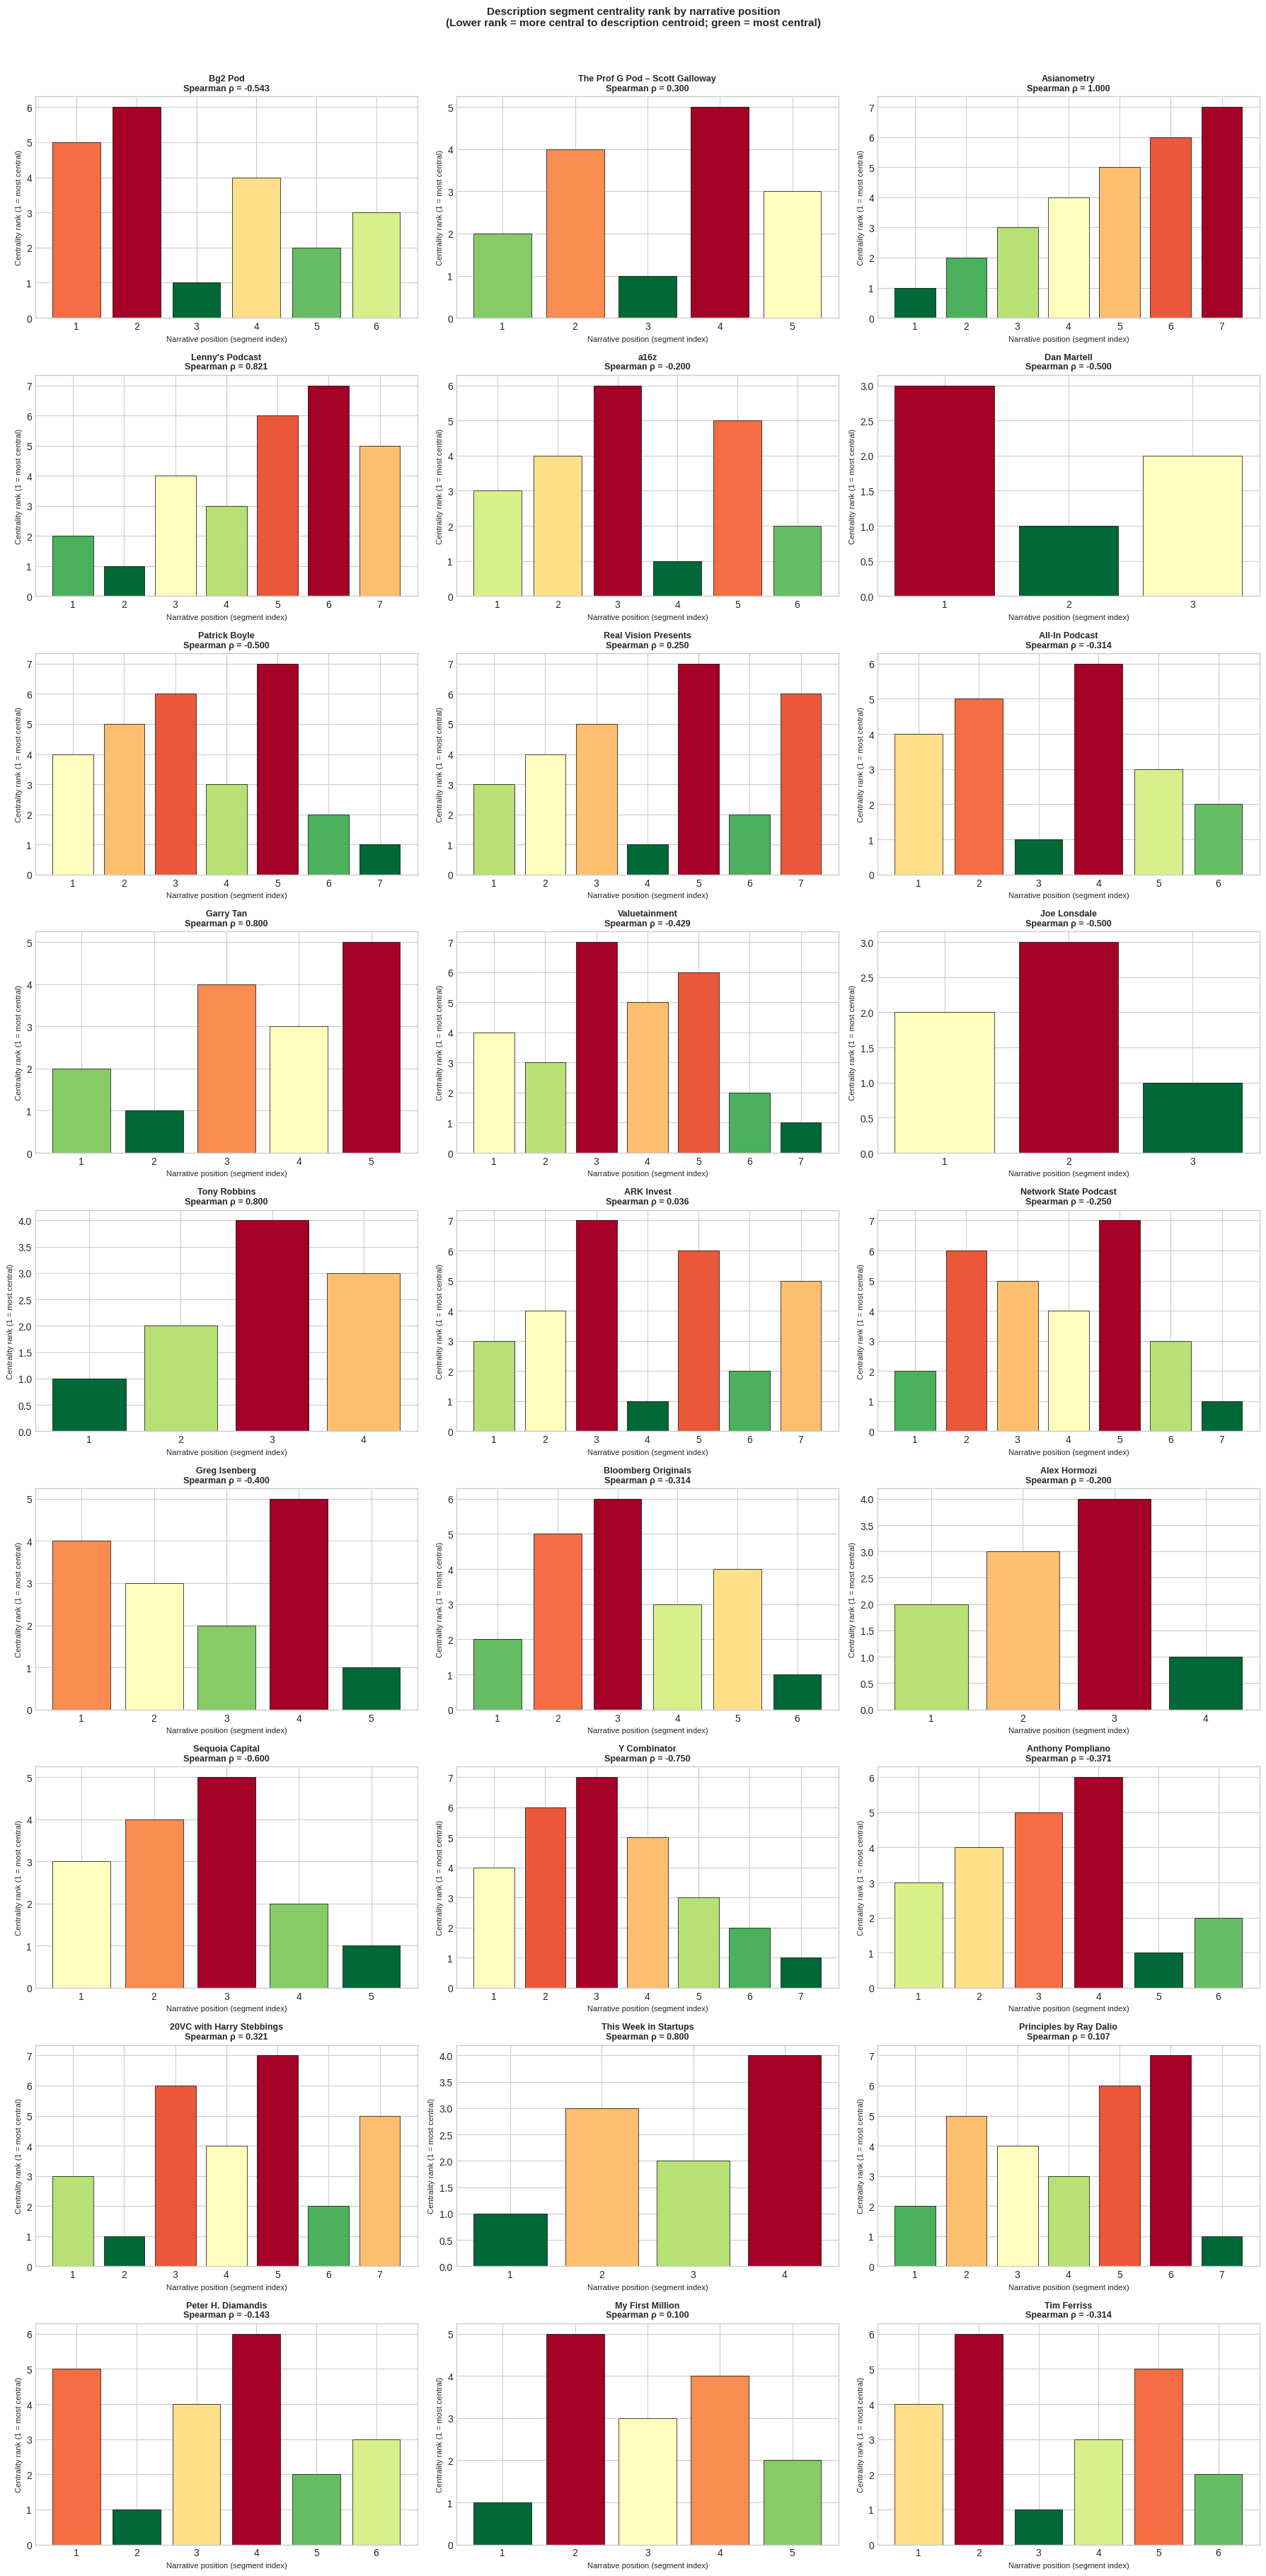

Saved → /content/drive/MyDrive/Research/centrality_analysis/latest/centrality_panels.png


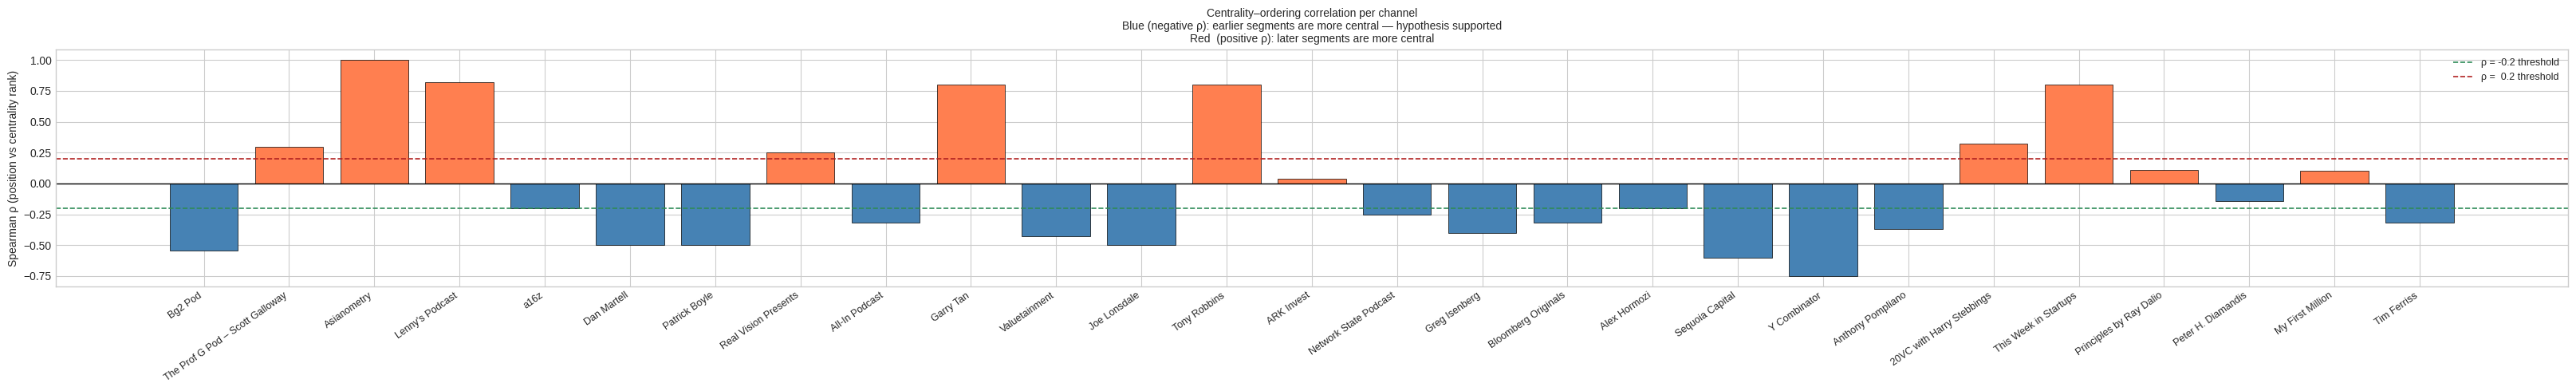

Saved → /content/drive/MyDrive/Research/centrality_analysis/latest/spearman_summary.png


In [6]:
n_ch   = len(channels)
n_cols = min(3, n_ch)
n_rows = (n_ch + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows),
                          squeeze=False)

cmap = plt.cm.RdYlGn_r    # low rank (most central) = green, high rank = red

for idx, ch in enumerate(channels):
    row_i, col_i = divmod(idx, n_cols)
    ax   = axes[row_i][col_i]
    seg_df = desc_centrality.get(ch)

    if seg_df is None:
        ax.set_visible(False)
        continue

    norm   = plt.Normalize(vmin=1, vmax=len(seg_df))
    colors = [cmap(norm(r)) for r in seg_df['desc_rank'].values]

    ax.bar(seg_df['segment_index'], seg_df['desc_rank'], color=colors, edgecolor='k', linewidth=0.5)
    ax.set_xlabel('Narrative position (segment index)', fontsize=8)
    ax.set_ylabel('Centrality rank (1 = most central)', fontsize=8)

    rho_val = corr_df['spearman_rho'].get(ch, float('nan'))
    ax.set_title(f'{ch}\nSpearman ρ = {rho_val:.3f}', fontsize=9, fontweight='bold')
    ax.set_xticks(seg_df['segment_index'].values)

# Hide any unused subplot panels
for idx in range(n_ch, n_rows * n_cols):
    row_i, col_i = divmod(idx, n_cols)
    axes[row_i][col_i].set_visible(False)

plt.suptitle('Description segment centrality rank by narrative position\n'
             '(Lower rank = more central to description centroid; green = most central)',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()

centrality_dir = RESEARCH_ROOT / 'centrality_analysis' / 'latest'
centrality_dir.mkdir(parents=True, exist_ok=True)
panels_path = centrality_dir / 'centrality_panels.png'
plt.savefig(panels_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {panels_path}')

# ---- Spearman ρ summary bar chart ----------------------------------------
fig2, ax2 = plt.subplots(figsize=(max(8, n_ch * 1.2), 5))
bar_colors = ['steelblue' if r < 0 else 'coral'
              for r in corr_df['spearman_rho'].values]
ax2.bar(range(len(corr_df)), corr_df['spearman_rho'].values,
        color=bar_colors, edgecolor='k', linewidth=0.5)
ax2.axhline(0,     color='k',   linewidth=1.0)
ax2.axhline(-0.2,  color='seagreen', linewidth=1.2, linestyle='--', label='ρ = -0.2 threshold')
ax2.axhline( 0.2,  color='firebrick',linewidth=1.2, linestyle='--', label='ρ =  0.2 threshold')
ax2.set_xticks(range(len(corr_df)))
ax2.set_xticklabels(corr_df.index.tolist(), rotation=35, ha='right', fontsize=9)
ax2.set_ylabel('Spearman ρ (position vs centrality rank)')
ax2.set_title('Centrality–ordering correlation per channel\n'
              'Blue (negative ρ): earlier segments are more central — hypothesis supported\n'
              'Red  (positive ρ): later segments are more central',
              fontsize=10)
ax2.legend(fontsize=9)
plt.tight_layout()
summary_path = centrality_dir / 'spearman_summary.png'
plt.savefig(summary_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {summary_path}')


## 7) Save artifacts

Export the correlation table and per-channel segment centrality data for further analysis.


In [7]:
# Correlation table
corr_df.round(6).to_csv(centrality_dir / 'centrality_ordering_correlation.csv')
print(f'Saved centrality_ordering_correlation.csv → {centrality_dir}')

# Per-channel segment detail (all channels in one CSV)
all_seg_rows = []
for ch, seg_df in desc_centrality.items():
    all_seg_rows.append(seg_df)

if all_seg_rows:
    full_seg_df = pd.concat(all_seg_rows, ignore_index=True)
    full_seg_df.to_csv(centrality_dir / 'segment_centrality_detail.csv', index=False)
    print(f'Saved segment_centrality_detail.csv → {centrality_dir}')

# Summary JSON
summary = {
    'schema_version': '1.0.0',
    'hypothesis': (
        'Earlier segments in a channel description are more semantically central '
        '(closer to the description centroid) — i.e., authors lead with core content.'
    ),
    'mean_spearman_rho': round(float(corr_df['spearman_rho'].mean()), 4),
    'n_channels_with_negative_rho': int((corr_df['spearman_rho'] < 0).sum()),
    'n_channels_hypothesis_supported': int((corr_df['spearman_rho'] < -0.2).sum()),
    'n_channels_total': len(corr_df),
    'per_channel': corr_df.reset_index().to_dict(orient='records'),
}

with open(centrality_dir / 'centrality_summary.json', 'w') as fh:
    json.dump(summary, fh, indent=2)

print(f'Saved centrality_summary.json → {centrality_dir}')
print()
print('=== Final result ===')
print(f"Mean Spearman ρ = {summary['mean_spearman_rho']}")
if summary['mean_spearman_rho'] < -0.2:
    print('Overall: hypothesis SUPPORTED — central ideas tend to appear earlier in descriptions.')
elif summary['mean_spearman_rho'] > 0.2:
    print('Overall: hypothesis REFUTED — central ideas tend to appear LATER.')
else:
    print('Overall: hypothesis INCONCLUSIVE — no strong ordering signal.')


Saved centrality_ordering_correlation.csv → /content/drive/MyDrive/Research/centrality_analysis/latest
Saved segment_centrality_detail.csv → /content/drive/MyDrive/Research/centrality_analysis/latest
Saved centrality_summary.json → /content/drive/MyDrive/Research/centrality_analysis/latest

=== Final result ===
Mean Spearman ρ = -0.0368
Overall: hypothesis INCONCLUSIVE — no strong ordering signal.
